# The no error weighted model: six uncertainty-interval methods, six fields

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d.glimmer import checkpoint as ckpt
from azt1d.glimmer import uncertainty as unc

plotting.apply_style()

CKPT_DIR = PROJECT_ROOT / "data" / "processed" / "checkpoints" / "cnn_lstm_v0"
METHOD_LABELS = {
    "Conformal": "Conformal (statistics, model-agnostic)",
    "GARCH": "GARCH (finance)",
    "Analog Ensemble": "Analog Ensemble (weather)",
    "EWMA": "EWMA volatility (finance, RiskMetrics)",
    "Normalized Conformal": "Locally weighted conformal (statistics)",
    "Time-of-day Quantiles": "Time-of-day quantiles (climatology)",
}

df = loading.load_real_dataset(PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data" / "processed")
subject_ids = sorted(int(s) for s in df["subject_id"].unique())

engines, actuals, frames, max_gap = {}, {}, {}, 0.0
for sid in subject_ids:
    res = ckpt.load_result(CKPT_DIR, sid)
    df_subject = df[df["subject_id"] == sid].reset_index(drop=True)
    val, test = unc.forecast_frames(res, df_subject)
    max_gap = max(max_gap, unc.matches_stored_predictions(test, res))
    engines[sid] = unc.BandEngine(val, test)
    actuals[sid] = test.actual
    frames[sid] = test

assert max_gap < 0.05, "rebuilt predictions do not match the checkpoints"
actual_all = np.concatenate([actuals[s] for s in subject_ids])
print(f"Rebuilt forecasts and bands for {len(subject_ids)} patients, {len(actual_all):,} test predictions.")

Rebuilt forecasts and bands for 25 patients, 60,009 test predictions.


## Band width vs. how wrong the forecast actually turned out to be

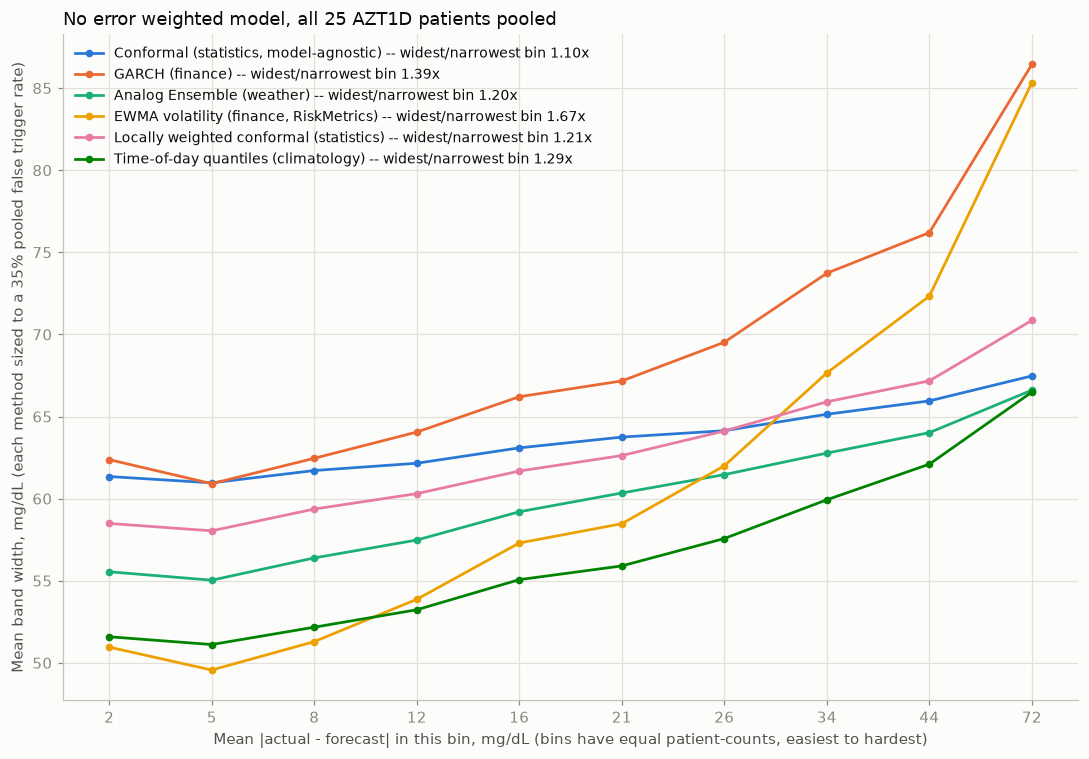

In [2]:
# The alarm trade-off curve (danger caught vs. false triggers) turns out nearly identical for all
# six methods -- expected, since it is driven mostly by the point forecast's own error distribution,
# which every method shares. The real question a band answers is sharper: does its width actually
# know, ahead of time, when the forecast is about to be badly wrong? All six bands are put on equal
# footing first (each sized to a 35% pooled false trigger rate, same as notebooks_2/01), then every
# test prediction is grouped by how large its eventual error turned out to be, and each method's
# average band width is plotted against that. A flat line means the method hands out the same size
# band whether the forecast is about to be right or badly wrong. A rising line means it saw it coming.
def pooled_bands(method, level):
    los, his = zip(*(engines[s].bands(method, level) for s in subject_ids))
    return np.concatenate(los), np.concatenate(his)


abs_err_all = np.concatenate([np.abs(frames[s].resid) for s in subject_ids])
N_BINS = 10
bin_id = pd.qcut(abs_err_all, N_BINS, labels=False)
bin_center = pd.Series(abs_err_all).groupby(bin_id).mean()

fig, ax = plt.subplots(figsize=(10, 7))
for method, color in zip(unc.ALL_METHODS, plotting.CATEGORICAL):
    level = unc.level_for_false_trigger_rate(engines, actuals, method, 0.35)
    lo, hi = pooled_bands(method, level)
    width_by_bin = pd.Series(hi - lo).groupby(bin_id).mean()
    ratio = width_by_bin.iloc[-1] / width_by_bin.iloc[0]
    ax.plot(range(N_BINS), width_by_bin.values, color=color, linewidth=1.8, marker="o", markersize=4,
             label=f"{METHOD_LABELS[method]} -- widest/narrowest bin {ratio:.2f}x")
ax.set_xticks(range(N_BINS))
ax.set_xticklabels([f"{v:.0f}" for v in bin_center.values])
ax.set_xlabel("Mean |actual - forecast| in this bin, mg/dL (bins have equal patient-counts, easiest to hardest)")
ax.set_ylabel("Mean band width, mg/dL (each method sized to a 35% pooled false trigger rate)")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("No error weighted model, all 25 AZT1D patients pooled", loc="left")
fig.tight_layout()
plt.show()